In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- CONFIGURACIÓN ---
# Ruta a la carpeta donde están los CSV
ruta_carpeta = r"C:\Users\david\Downloads\reneuroborosdescargardatos"   # ← cámbiala, por ejemplo: "C:/Users/D/Documents/bienestar_datos"

# Columnas de interés (ajusta nombres exactamente a tus CSV)
columnas = [
    '\ufeff"ID"', "Data",
    "Son", "Exercici físic", "Dieta", "Dispositius mòbils", "Relacions socials",
    "Satisfacció", "Calma", "Poder"
]


In [3]:
# --- LECTURA DE TODOS LOS CSV ---
dfs = []  # lista donde guardaremos cada DataFrame limpio

for archivo in os.listdir(ruta_carpeta):
    if archivo.endswith(".csv"):
        ruta = os.path.join(ruta_carpeta, archivo)
        try:
            # Leer CSV (detecta separador automáticamente)
            df = pd.read_csv(ruta, encoding="utf-8", sep=None, engine="python")
            
            # Filtrar columnas de interés (solo si existen)
            columnas_presentes = [col for col in columnas if col in df.columns]
            df = df[columnas_presentes]

            # Eliminar filas con datos faltantes
            df = df.dropna(subset=columnas_presentes)
                        
            # Añadir al listado de DataFrames
            dfs.append(df)
            print(f"✅ Cargado {archivo}: {df.shape[0]} filas válidas")

        except Exception as e:
            print(f"⚠️ Error al leer {archivo}: {e}")


# --- UNIFICAR TODOS LOS CSV ---
if dfs:
    df_total = pd.concat(dfs, ignore_index=True)
    df_total = df_total.rename(columns={'\ufeff"ID"': 'ID'})
    print(f"\n📊 DataFrame combinado: {df_total.shape[0]} filas, {df_total.shape[1]} columnas")
else:
    df_total = pd.DataFrame(columns=columnas)
    print("⚠️ No se cargó ningún archivo CSV válido.")

✅ Cargado classroom-660313e93365e948487826c7-data-2025-09-08.csv: 24 filas válidas
✅ Cargado classroom-66042c413365e948487828cb-data-2025-09-08.csv: 23 filas válidas
✅ Cargado classroom-66053bb43365e94848782b0a-data-2025-09-08.csv: 259 filas válidas
✅ Cargado classroom-661658927ddbe1c2e6cd6206-data-2025-09-08.csv: 218 filas válidas
✅ Cargado classroom-661e78767ddbe1c2e6cd6a1c-data-2025-09-08.csv: 94 filas válidas
✅ Cargado classroom-661f96157ddbe1c2e6cd6bca-data-2025-09-08.csv: 102 filas válidas
✅ Cargado classroom-661fdb5d7ddbe1c2e6cd6cd4-data-2025-09-08.csv: 681 filas válidas
✅ Cargado classroom-661fdc667ddbe1c2e6cd6cff-data-2025-09-08.csv: 1109 filas válidas
✅ Cargado classroom-66dabaef97690661a55b7f4f-data-2025-09-08.csv: 67 filas válidas
✅ Cargado classroom-66db23ed97690661a55b80ba-data-2025-09-08.csv: 479 filas válidas
✅ Cargado classroom-66db287097690661a55b80ee-data-2025-09-08.csv: 342 filas válidas
✅ Cargado classroom-66e31b60b3275893657df36b-data-2025-09-08.csv: 271 filas vál

In [4]:
df_total

,ID,Data,Son,Exercici físic,Dieta,Dispositius mòbils,Relacions socials,Satisfacció,Calma,Poder
0,660313e93365e948487826c4,2024-03-27T15:16:28.219Z,1.00,0.33,1.00,1.00,0.33,8.0,3.0,7.0
1,660313e93365e948487826c4,2024-03-28T07:30:51.708Z,1.00,0.66,1.00,0.66,1.00,3.0,3.0,3.0
2,660313e93365e948487826c4,2024-04-02T14:20:26.642Z,0.00,0.00,0.00,0.66,0.66,8.0,5.0,6.0
3,660313e93365e948487826c4,2024-04-07T17:48:27.673Z,0.66,0.66,0.00,0.66,0.33,8.0,3.0,7.0
4,660313e93365e948487826c4,2024-04-09T06:52:39.134Z,0.00,0.00,0.00,0.66,0.00,5.0,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...
5679,67d9538e47f528825b56d417,2025-03-19T08:34:08.828Z,1.00,0.33,1.00,0.66,1.00,10.0,7.0,7.0
5680,67d9538e47f528825b56d417,2025-03-20T08:02:28.923Z,1.00,0.00,0.66,0.33,1.00,7.0,2.0,4.0
5681,67d9538e47f528825b56d417,2025-03-27T08:03:37.074Z,0.33,0.33,1.00,0.00,1.00,3.0,3.0,5.0
5682,67d9538e47f528825b56d417,2025-03-31T13:13:25.161Z,1.00,0.33,1.00,0.66,0.00,8.0,8.0,7.0


In [5]:
df_total["Data"] = pd.to_datetime(df_total["Data"], errors="coerce", utc=True).dt.tz_convert(None).dt.normalize()

# Ordena por sujeto y fecha (buena práctica)
df_total = df_total.sort_values(["ID", "Data"]).copy()

# Día de intervención = días calendario desde el primer registro del sujeto + 1
primer_dia = df_total.groupby("ID")["Data"].transform("min")
df_total["dia_intervencion"] = (df_total["Data"] - primer_dia).dt.days + 1

df_total


,ID,Data,Son,Exercici físic,Dieta,Dispositius mòbils,Relacions socials,Satisfacció,Calma,Poder,dia_intervencion
0,660313e93365e948487826c4,2024-03-27,1.00,0.33,1.00,1.00,0.33,8.0,3.0,7.0,1
1,660313e93365e948487826c4,2024-03-28,1.00,0.66,1.00,0.66,1.00,3.0,3.0,3.0,2
2,660313e93365e948487826c4,2024-04-02,0.00,0.00,0.00,0.66,0.66,8.0,5.0,6.0,7
3,660313e93365e948487826c4,2024-04-07,0.66,0.66,0.00,0.66,0.33,8.0,3.0,7.0,12
4,660313e93365e948487826c4,2024-04-09,0.00,0.00,0.00,0.66,0.00,5.0,5.0,5.0,14
...,...,...,...,...,...,...,...,...,...,...,...
4555,67ea421a47f528825b5772c9,2025-04-06,1.00,1.00,0.33,0.66,0.66,8.0,3.0,5.0,7
4556,67ea421a47f528825b5772c9,2025-04-07,0.33,1.00,0.00,0.66,1.00,8.0,3.0,5.0,8
4557,67ea421a47f528825b5772c9,2025-05-11,1.00,0.66,0.33,0.66,0.00,5.0,5.0,5.0,42
5199,67ee42c947f528825b57cab3,2025-04-03,0.00,0.66,1.00,0.66,1.00,5.0,5.0,5.0,1


count    414.000000
mean      13.729469
std       12.595178
min        1.000000
25%        5.000000
50%       11.000000
75%       19.000000
max       87.000000
Name: n_registros, dtype: float64


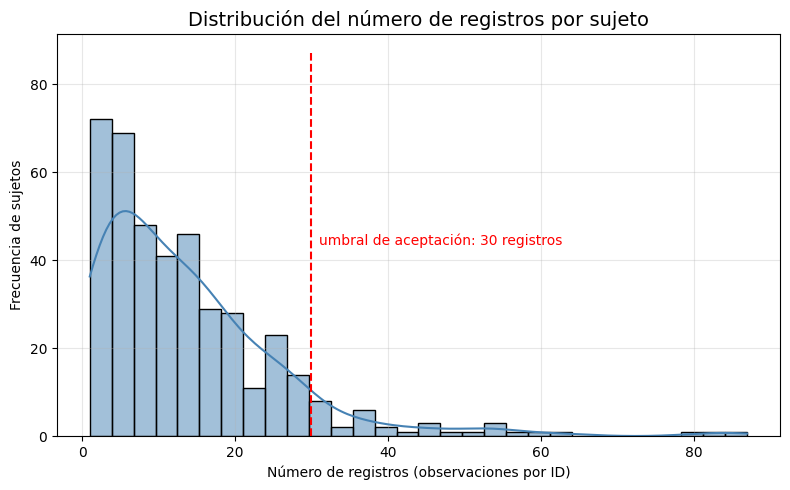

In [6]:
# Contar cuántas filas hay por ID
conteo = df_total["ID"].value_counts().sort_index()
conteo_df = conteo.reset_index()
conteo_df.columns = ["ID", "n_registros"]

# Mostrar estadísticas rápidas
print(conteo_df["n_registros"].describe())

# Gráfico de distribución
plt.figure(figsize=(8, 5))
sns.histplot(conteo_df["n_registros"], bins=30, kde=True, color="steelblue")
plt.title("Distribución del número de registros por sujeto", fontsize=14)
plt.xlabel("Número de registros (observaciones por ID)")
plt.ylabel("Frecuencia de sujetos")
umbral = 30
plt.plot([umbral,umbral], [0, conteo_df["n_registros"].max()], color='r', linestyle='--')
plt.text(x=umbral+1, y= conteo_df["n_registros"].max()/2, s=f'umbral de aceptación: {umbral} registros', color='r')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show(block=False)

In [7]:
# --- 3. Filtrar sujetos con al menos 20 registros ---
ids_validos = conteo_df.loc[conteo_df["n_registros"] >= umbral, "ID"]

df_filtrado = df_total[df_total["ID"].isin(ids_validos)].copy()

print(f"✅ Sujetos retenidos: {len(ids_validos)} de {conteo_df.shape[0]}")
print(f"📊 Filas finales: {df_filtrado.shape[0]} (umbral ≥ {umbral} registros)")

✅ Sujetos retenidos: 33 de 414
📊 Filas finales: 1484 (umbral ≥ 30 registros)


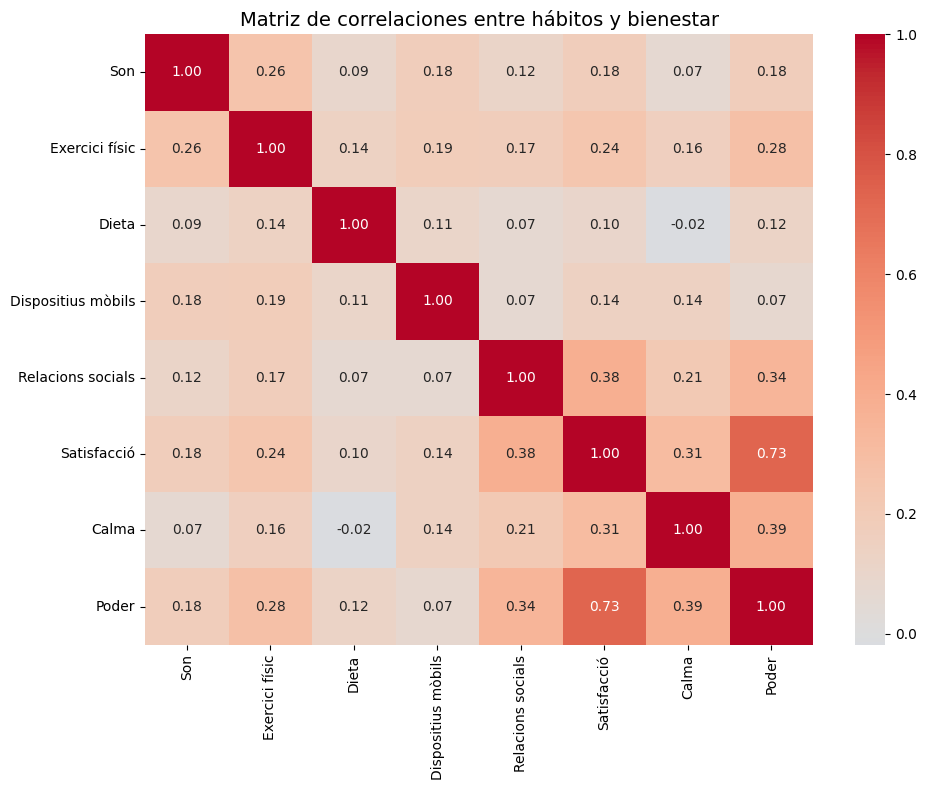

In [8]:
# --- 1. Correlaciones entre todas las variables ---
plt.figure(figsize=(10, 8))
corr = df_filtrado[["Son", "Exercici físic", "Dieta", "Dispositius mòbils", "Relacions socials",
    "Satisfacció", "Calma", "Poder"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlaciones entre hábitos y bienestar", fontsize=14)
plt.tight_layout()
plt.show()

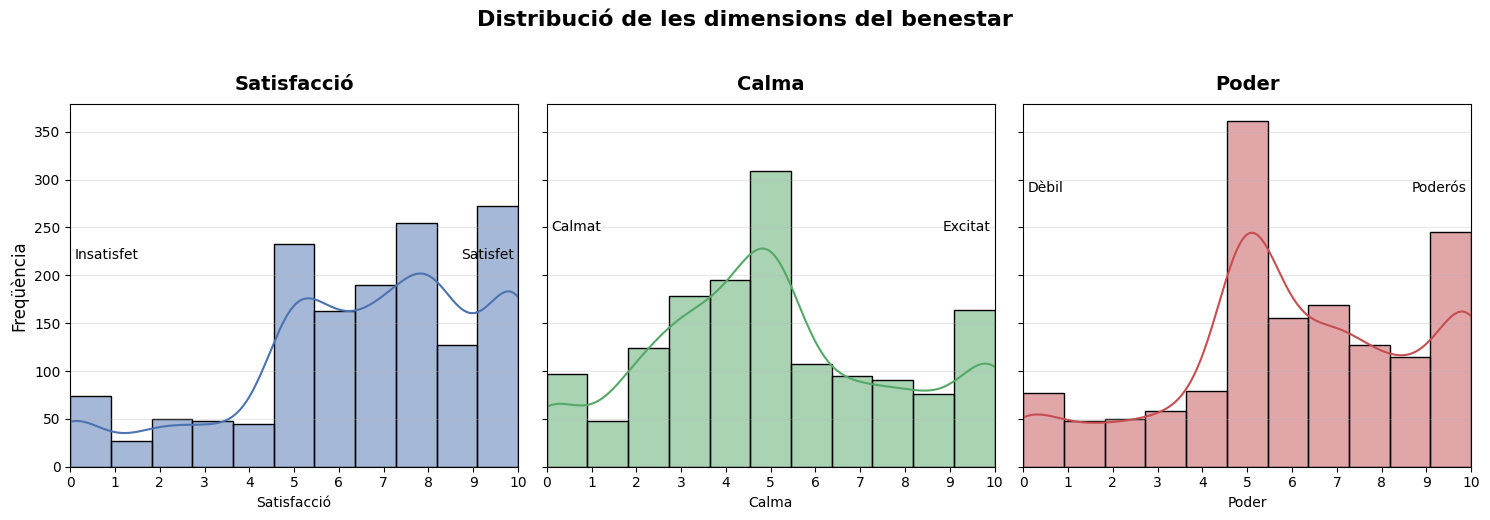

In [9]:
# Variables de bienestar (usa los nombres exactos de tus columnas)
variables = ["Satisfacció", "Calma", "Poder"]
titulos = ["Satisfacció", "Calma", "Poder"]
colores = ["#4C72B0", "#55A868", "#C44E52"]
etiquetas = [
    ("Insatisfet", "Satisfet"),
    ("Calmat", "Excitat"),
    ("Dèbil", "Poderós")
]

# Crear figura con 3 subplots en la misma fila
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, var in enumerate(variables):
    sns.histplot(df_filtrado[var], bins=11, kde=True, color=colores[i], ax=axes[i])
    axes[i].set_title(titulos[i], fontsize=14, weight="bold", pad=10)
    axes[i].set_xlim(0, 10)
    axes[i].set_xticks(range(0, 11))
    axes[i].grid(axis="y", alpha=0.3)
    
    # Etiquetas semánticas en extremos del eje X
    axes[i].text(0.1, axes[i].get_ylim()[1]*0.75, etiquetas[i][0],
                 ha="left", va="bottom", fontsize=10, color="k")
    axes[i].text(9.9, axes[i].get_ylim()[1]*0.75, etiquetas[i][1],
                 ha="right", va="bottom", fontsize=10, color="k")

    if i == 0:
        axes[i].set_ylabel("Freqüència", fontsize=12)
    else:
        axes[i].set_ylabel("")

# Título global
fig.suptitle("Distribució de les dimensions del benestar", fontsize=16, weight="bold", y=1.03)
plt.tight_layout()
plt.show()


In [10]:
## Modelos

In [11]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd

df = df_filtrado.copy()

In [12]:
#GLM
# Lista de predictores
df.columns = df.columns.str.replace(" ", "_").str.replace("ò", "o").str.replace("í", "i").str.replace("ó", "o").str.lower()

predictoras = ['son', 'exercici_fisic', 'dieta', 'dispositius_mobils',
       'relacions_socials']

# 1. Modelo para cada variable de bienestar
resultados = {}

for y in ['satisfaccio', 'calma', 'poder']:
    formula = f"{y} ~ {' + '.join(predictoras)}"
    model = smf.glm(formula=formula, data=df,
                    family=sm.families.Gaussian(sm.families.links.identity()))
    res = model.fit()
    resultados[y] = res

    print("\n" + "="*70)
    print(f"📈 Modelo para {y.upper()}")
    print(res.summary())
    print("="*70)


📈 Modelo para SATISFACCIO
                 Generalized Linear Model Regression Results                  
Dep. Variable:            satisfaccio   No. Observations:                 1484
Model:                            GLM   Df Residuals:                     1478
Model Family:                Gaussian   Df Model:                            5
Link Function:               identity   Scale:                          6.0689
Method:                          IRLS   Log-Likelihood:                -3440.7
Date:                Wed, 08 Oct 2025   Deviance:                       8969.8
Time:                        14:03:47   Pearson chi2:                 8.97e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2119
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept

C:\Users\david\anaconda3\envs\python3.10\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(
C:\Users\david\anaconda3\envs\python3.10\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(
C:\Users\david\anaconda3\envs\python3.10\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [13]:
#GLM-Mixed (random intercepts)

print("\n" + "="*70)
print(f"📈 Modelo para SATISFACCIO")
modelo_mixto = smf.mixedlm(
    "satisfaccio ~ son+ exercici_fisic + dieta + dispositius_mobils + relacions_socials",
    data=df,
    groups=df['id']
)
res_mixto = modelo_mixto.fit()
print(res_mixto.summary())
print("="*70)


print("\n" + "="*70)
print(f"📈 Modelo para CALMA")
modelo_mixto = smf.mixedlm(
    "calma ~ son+ exercici_fisic + dieta + dispositius_mobils + relacions_socials",
    data=df,
    groups=df['id']
)
res_mixto = modelo_mixto.fit()
print(res_mixto.summary())
print("="*70)

print("\n" + "="*70)
print(f"📈 Modelo para PODER")
modelo_mixto = smf.mixedlm(
    "poder ~ son+ exercici_fisic + dieta + dispositius_mobils + relacions_socials",
    data=df,
    groups=df['id']
)
res_mixto = modelo_mixto.fit()
print(res_mixto.summary())
print("="*70)


📈 Modelo para SATISFACCIO
           Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: satisfaccio
No. Observations:   1484    Method:             REML       
No. Groups:         33      Scale:              4.2306     
Min. group size:    30      Log-Likelihood:     -3228.2857 
Max. group size:    87      Converged:          Yes        
Mean group size:    45.0                                   
-----------------------------------------------------------
                   Coef. Std.Err.   z   P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept          3.717    0.378 9.832 0.000  2.976  4.458
son                0.375    0.167 2.250 0.024  0.048  0.702
exercici_fisic     0.803    0.212 3.791 0.000  0.388  1.218
dieta              0.494    0.182 2.705 0.007  0.136  0.851
dispositius_mobils 0.643    0.215 2.983 0.003  0.220  1.065
relacions_socials  1.805    0.200 9.026 0.000  1.413  2.196
Group Var          2.113

In [14]:
# import bambi as bmb

# model = bmb.Model(
#     "satisfaccio ~ son+ exercici_fisic + dieta + dispositius_mobils + relacions_socials + (1|id)",
#     df, family="gaussian"
# )
# idata = model.fit(draws=2000, chains=4, target_accept=0.9)
# model.summary()

In [ ]:
%%capture --no-stderr

#Modelo multivariante jerárquico (PyMC): random intercepts correlacionados + residuos correlacionados

import pymc as pm
from tqdm import tqdm
import arviz as az

# Predictores (escala 0–1); estandarizamos para estabilidad numérica
Xcols = ['son', 'exercici_fisic', 'dieta', 'dispositius_mobils', 'relacions_socials']

X = df[Xcols].astype(float)
X = (X - X.mean()) / X.std(ddof=0)
X = X.to_numpy()  # (N, P)
P = X.shape[1]

# Resultado multivariante: ordenamos columnas en vec Y = [satisfaccion, calma, poder]
Ycols = ['satisfaccio','calma','poder']
Y = df[Ycols].astype(float).to_numpy()  # (N, 3)
N, K = Y.shape  # K=3

# Índices de sujeto
ids = pd.Categorical(df['id'])
J = len(ids.categories)
subj_idx = ids.codes  # (N,)

with pm.Model() as model:
    # ----- Priors de efectos fijos -----
    # Interceptos para cada outcome
    alpha = pm.Normal("alpha", 0.0, 1.0, shape=K)  # (3,)
    # Betas por outcome y predictor (matriz K x P)
    beta = pm.Normal("beta", 0.0, 1.0, shape=(K, P))  # (3, P)

    # ----- Random intercepts por sujeto (correlacionados entre outcomes) -----
    # Matriz de covarianza a nivel sujeto: Sigma_u (KxK), via LKJ
    sd_u = pm.HalfNormal("sd_u", 1.0, shape=K)
    chol_u, corr_u, sigma_u = pm.LKJCholeskyCov(
        "Sigma_u", n=K, eta=2.0, sd_dist=pm.HalfNormal.dist(1.0), compute_corr=True
    )
    # Interceptos aleatorios por sujeto ~ MVN(0, Sigma_u)
    z_u = pm.Normal("z_u", 0.0, 1.0, shape=(J, K))
    u = pm.Deterministic("u", z_u @ chol_u.T)  # (J, K)

    # ----- Residuos a nivel observación (correlacionados entre outcomes) -----
    sd_e = pm.HalfNormal("sd_e", 1.0, shape=K)
    chol_e, corr_e, sigma_e = pm.LKJCholeskyCov(
        "Sigma_e", n=K, eta=2.0, sd_dist=pm.HalfNormal.dist(1.0), compute_corr=True
    )

    # ----- Media lineal para cada observación y outcome -----
    # mu[i, k] = alpha[k] + X[i,:] @ beta[k,:] + u[subj_idx[i], k]
    mu = alpha + (X @ beta.T) + u[subj_idx]  # (N, K)

    # ----- Verosimilitud multivariante -----
    Y_obs = pm.MvNormal("Y_obs", mu=mu, chol=chol_e, observed=Y)

    idata = pm.sample(2000, tune=2000, target_accept=0.9, chains=4, random_seed=42, progressbar=True)
    az.summary(idata, var_names=["alpha","beta","sd_u","sd_e","Sigma_u","Sigma_e"])


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sd_u, Sigma_u, z_u, sd_e, Sigma_e]
